# Setup

In [1]:
# Standard library imports
import warnings

# Third-party imports: core data -> modeling -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.mlemodel import MLEModel
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# Configuration & settings
warnings.simplefilter(action="ignore")        # silence optimizer/frequency chatter

This section of code imports necessary libraries for data analysis and time series modeling. 

First, it includes the `warnings` module from Python’s standard library to manage warning messages that might appear during execution. Specifically, it configures the program to ignore warnings, which can be useful to declutter output when you are focused on results rather than minor technical details.

Next, several core data science and statistical libraries are imported: `numpy` for numerical operations (especially working with arrays), `pandas` for data manipulation and analysis using DataFrames, and `matplotlib.pyplot` for creating visualizations like plots and charts. 

Following these, the code imports modules from the `statsmodels` library, a powerful tool for statistical modeling. It brings in the main API (`sm`), functions for testing stationarity of time series data (`adfuller`), a base class for maximum likelihood estimation models (`MLEModel`), and tools specifically designed for exponential smoothing models (`ETSModel`).

The final line suppresses warnings related to optimization processes or frequency-related calculations within `statsmodels`, further streamlining the output.

The script initializes an environment tailored for time series analysis and statistical modeling. By using `warnings.simplefilter(action="ignore")`, it suppresses all warning messages, which prevents output clutter caused by optimizer convergence issues or frequency mismatches during model execution.

Data manipulation is managed through `numpy` for numerical arrays and `pandas` for structured dataframes. The `matplotlib.pyplot` library is included to facilitate the visualization of data and statistical results.

The core analytical capabilities come from the `statsmodels` library. Specifically, it imports `adfuller` to perform the Augmented Dickey-Fuller test for checking stationarity in time series data. It also includes `MLEModel` for working with Maximum Likelihood Estimation in state-space models and `ETSModel` for performing exponential smoothing forecasts based on error, trend, and seasonality components.

In [2]:
# general settings
class CFG:
    data_folder      = './data/'
    graph_folder     = './graphs/'
    img_dim1         = 14
    img_dim2         = 6
    SEED             = 42
    HORIZON          = 24        # months held out for forecast evaluation
    SEASONAL_PERIODS = 12        # monthly data -> annual seasonal cycle
    metric           = 'rmse'

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

This code defines configuration settings and adjusts the display style for subsequent data analysis and visualization tasks.

A class named `CFG` is created to hold various parameters as attributes. These include: the path to the directory where data files are stored (`data_folder`), the location for saving generated graphs (`graph_folder`), dimensions for plot sizes (`img_dim1`, `img_dim2`), a random seed value for reproducibility (`SEED`), the number of months to reserve for evaluating forecast accuracy (`HORIZON`), the length of the seasonal cycle in the data (assuming monthly data with an annual pattern, set to 12 – `SEASONAL_PERIODS`), and the metric used to assess forecast performance (`metric`, set to root mean squared error or 'rmse').

The code then customizes the appearance of plots using `matplotlib`. It applies the "seaborn-v0_8" style for a visually appealing aesthetic, and sets the default figure size based on the dimensions defined in the `CFG` class. 

Finally, it initializes the NumPy random number generator with the seed value specified in `CFG.SEED`, ensuring that any randomized operations produce consistent results across multiple runs of the code.

# Utils


In [3]:
def forecast_metrics(actual, predicted):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = float(np.round(np.mean(np.abs(actual - predicted)), 2))
    rmse = float(np.round(np.sqrt(np.mean((actual - predicted) ** 2)), 2))
    return {"MAE": mae, "RMSE": rmse}

This code defines a function called `forecast_metrics` that calculates and returns the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) between two sets of numerical values – representing actual and predicted data.

The function first converts both input arrays (`actual` and `predicted`) into NumPy arrays with a floating-point data type to ensure accurate calculations. It then computes the MAE by taking the absolute difference between each corresponding element in the two arrays, calculating their average, and rounding the result to two decimal places. 

Similarly, it calculates the RMSE by finding the squared difference between each pair of elements, computing their average, taking the square root of that average, and again rounding to two decimal places. 

Finally, the function returns a dictionary containing both the MAE and RMSE values, labeled with keys "MAE" and "RMSE," respectively. This provides a convenient way to access both metrics after calling the function.

In [4]:
def train_valid_split(series, horizon=CFG.HORIZON):
    """Chronological split: everything but the last `horizon` points vs. those points."""
    return series.iloc[:-horizon], series.iloc[-horizon:]

This code defines a function named `train_valid_split` that divides a time series into training and validation (or testing) sets based on a chronological split.

The function takes a time series (`series`) – likely a Pandas Series – and an optional argument `horizon`, which defaults to the value of `CFG.HORIZON` defined earlier. The `horizon` parameter determines how many data points from the end of the series will be reserved for validation. 

The function returns two parts of the original time series: the first part consists of all data points *except* the last `horizon` points, and this is designated as the training set. The second part comprises only the final `horizon` data points, which form the validation set. This split preserves the temporal order of the data, making it suitable for evaluating how well a model generalizes to future observations.

In [5]:
def print_adf_result(series, name="series"):
    """Run an Augmented Dickey-Fuller test and print a readable verdict."""
    result = adfuller(series.dropna())          # the test cannot handle NaNs
    print(f"ADF test for {name}")
    print(f"  ADF statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  verdict       : {'stationary (reject unit root)' if result[1] < 0.05 else 'non-stationary (cannot reject unit root)'}")

This code defines a function called `print_adf_result` that performs an Augmented Dickey-Fuller (ADF) test on a time series and presents the results in a user-friendly format.

The function takes a time series (`series`) and an optional name (`name`) for identification as input. It first runs the ADF test using `adfuller()` from the `statsmodels` library, after removing any missing values (NaNs) from the series because the test cannot handle them. 

Then, it prints informative output to the console: the name of the time series being tested, the ADF statistic value formatted to four decimal places, the p-value associated with the test also formatted to four decimal places, and a clear verdict indicating whether the time series is considered stationary or non-stationary. The verdict is based on comparing the p-value to a significance level of 0.05; if the p-value is less than 0.05, the null hypothesis (that the series has a unit root and is therefore non-stationary) is rejected, indicating stationarity. Otherwise, the null hypothesis cannot be rejected, suggesting that the series is likely non-stationary.

In [6]:
def plot_forecast(train, valid, fc_mean, lower=None, upper=None, title="", fitted=None):
    """Standard forecast chart: observed, optional fitted, forecast, optional interval."""
    fig, ax = plt.subplots()
    ax.plot(train.index, train.values, lw=2, label="Observed (train)")
    ax.plot(valid.index, valid.values, lw=2, color="#333333", label="Actual (holdout)")
    if fitted is not None:
        ax.plot(fitted.index, fitted.values, color="red", lw=1.5, alpha=0.8, label="Fitted")
    ax.plot(fc_mean.index, fc_mean.values, color="green", linestyle="--", marker="o",
            markersize=4, lw=2, label="Forecast")
    if lower is not None and upper is not None:
        ax.fill_between(fc_mean.index, lower, upper, color="green", alpha=0.15,
                        label="95% interval")
    ax.set_title(title); ax.set_xlabel("")
    plt.legend(loc="upper left"); plt.show()

This code defines a function called `plot_forecast` that generates a visualization of time series data, including training data, actual values in a validation set, forecasts, and optionally fitted values and prediction intervals.

The function takes several arguments: the training time series (`train`), the validation (or holdout) time series (`valid`), the forecasted values (`fc_mean`), optional lower and upper bounds for a confidence interval (`lower`, `upper`), an optional title for the plot (`title`), and optionally fitted values from a model (`fitted`).

It begins by creating a Matplotlib figure and axes object. It then plots the training data as a solid line, labeled "Observed (train)". Next, it plots the actual validation data as a solid gray line, labeled “Actual (holdout)”. If `fitted` values are provided, they are plotted as a red line with some transparency, labeled "Fitted". 

The forecasted values (`fc_mean`) are then plotted as a dashed green line with markers, labeled "Forecast."  If lower and upper bounds for a prediction interval are given, the area between them is shaded in light green, representing a 95% confidence interval. Finally, it sets the plot title (if provided), removes the x-axis label, displays a legend in the upper left corner, and shows the resulting plot. This function provides a comprehensive visual assessment of forecast performance by comparing predictions to observed data.

In [7]:
def compare_models(scores, baseline):
    """Turn a {name: rmse} dict into a tidy table with delta-vs-baseline and a flag."""
    rows = []
    for name, rmse in scores.items():
        rows.append({"model": name, "RMSE": rmse,
                     "delta_vs_baseline": float(np.round(rmse - scores[baseline], 2)),
                     "improved": rmse < scores[baseline]})
    return pd.DataFrame(rows).set_index("model").sort_values("RMSE")

This code defines a function called `compare_models` that analyzes the performance of multiple models by comparing their Root Mean Squared Error (RMSE) values to a baseline model and presenting the results in a structured table.

The function takes two arguments: a dictionary named `scores`, where keys are model names and values are their corresponding RMSE scores, and the name of the baseline model (`baseline`). 

It initializes an empty list called `rows` to store data for each model. It then iterates through the `scores` dictionary, extracting the model name and its RMSE score for each iteration. For each model, it calculates the difference between its RMSE and the baseline model’s RMSE (rounded to two decimal places), and determines whether the model's performance is an improvement over the baseline by checking if its RMSE is lower. 

It appends a dictionary containing the model name, its RMSE, the delta compared to the baseline, and a boolean flag indicating improvement to the `rows` list. Finally, it converts the `rows` list into a Pandas DataFrame, sets the "model" column as the index, sorts the DataFrame by the "RMSE" column in ascending order (so the best-performing model is at the top), and returns the resulting DataFrame. This provides a clear and concise comparison of different models’ performance relative to a baseline.

# Groundwork

In [8]:
# The Nile: annual flow volume at Aswan, 1871-1970 (ships with statsmodels)
nile_raw = sm.datasets.nile.load_pandas().data
nile_y = pd.Series(nile_raw["volume"].values,
                   index=pd.date_range("1871", periods=len(nile_raw), freq="YS"),
                   name="volume")
print("observations:", len(nile_y), " span:", nile_y.index[0].year, "-", nile_y.index[-1].year)
nile_y.head(3)

observations: 100  span: 1871 - 1970


1871-01-01    1120.0
1872-01-01    1160.0
1873-01-01     963.0
Freq: YS-JAN, Name: volume, dtype: float64

This code loads and prepares the Nile River annual flow dataset for time series analysis.

It begins by loading the Nile dataset from the `statsmodels` library using `sm.datasets.nile.load_pandas()`. This function returns a Pandas DataFrame containing the data. The code then extracts the "volume" column from this DataFrame and converts it into a Pandas Series named `nile_y`. 

A date range is created as the index for the series, starting in 1871 with a frequency of “YS” (year start), matching the length of the original data. The name of the series is set to "volume". 

The code then prints information about the dataset: the number of observations and the time span covered by the data, indicating the first and last years included in the series. Finally, it displays the first three values of the `nile_y` Series using `.head(3)`, allowing a quick inspection of the data. This prepares the Nile River flow data for further analysis, such as stationarity testing or forecasting.

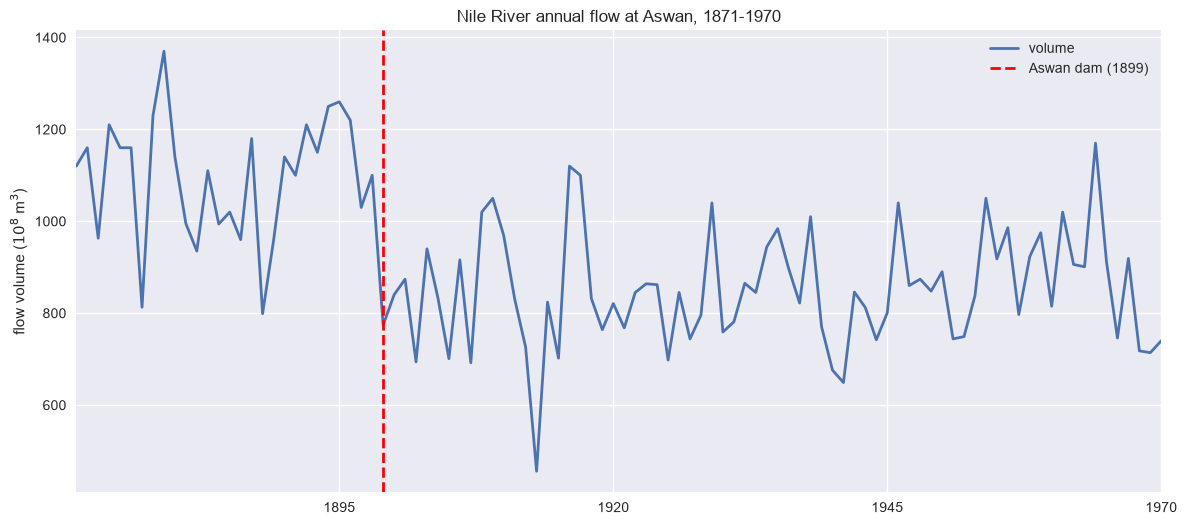

In [9]:
ax = nile_y.plot(lw=2, title="Nile River annual flow at Aswan, 1871-1970")
ax.axvline(pd.Timestamp("1899-01-01"), color="red", linestyle="--", lw=2,
           label="Aswan dam (1899)")
ax.set_xlabel(""); ax.set_ylabel("flow volume ($10^8$ m$^3$)")
plt.legend(); plt.show()

This code generates a line plot visualizing the Nile River’s annual flow data and highlights the construction of the Aswan Dam.

It starts by plotting the `nile_y` time series using the `.plot()` method, creating a line graph with a linewidth of 2 and setting the title to "Nile River annual flow at Aswan, 1871-1970". The resulting axes object is assigned to the variable `ax`.

A vertical line is then added to the plot using `ax.axvline()`, representing the year the Aswan Dam was constructed (1899). This line is colored red, styled as a dashed line, has a linewidth of 2, and includes a label "Aswan dam (1899)".

The x-axis label is removed using `ax.set_xlabel("")`, and the y-axis label is set to “flow volume ($10^8$ m$^3$)”, indicating the units of measurement. Finally, a legend is displayed using `plt.legend()`, and the plot is shown on the screen using `plt.show()`. This visualization allows for a quick understanding of the Nile’s flow pattern over time and highlights the potential impact of the Aswan Dam on the river's hydrology.

In [10]:
print_adf_result(nile_y, name="Nile volume")

ADF test for Nile volume
  ADF statistic : -4.0487
  p-value       : 0.0012
  verdict       : stationary (reject unit root)



This code executes an Augmented Dickey-Fuller (ADF) test on the Nile River annual flow data and prints the results to the console.

It calls the `print_adf_result` function, passing in the `nile_y` time series as input and setting the name of the series to "Nile volume". The function performs the ADF test, calculates the test statistic and p-value, and then prints these values along with a verdict indicating whether the time series is considered stationary or non-stationary based on the significance level of 0.05. This helps determine if the Nile River flow data has a unit root and requires differencing to achieve stationarity before applying certain time series models.

## Hand-built Kalman filter


In [11]:
class DKStateSpaceModel:
    """Minimal Durbin-Koopman Kalman filter for a univariate linear Gaussian model.

        y_t     = Z * alpha_t + eps_t,   eps ~ N(0, H)
        alpha_{t+1} = T * alpha_t + R * eta_t,   eta ~ N(0, Q)

    Scalars throughout (one state, one observation) - enough to see the machinery.
    """
    def __init__(self, y, T, Z, R, Q, H, a1, P1):
        self.y = np.asarray(y, dtype=float)
        self.T, self.Z, self.R = float(T), float(Z), float(R)
        self.Q, self.H = float(Q), float(H)
        self.a1, self.P1 = float(a1), float(P1)
        self.n = len(self.y)

    def filter(self):
        a = np.zeros(self.n + 1)      # predicted state:      a_t = E[alpha_t | y_{1..t-1}]
        P = np.zeros(self.n + 1)      # its variance
        v = np.zeros(self.n)          # innovations
        F = np.zeros(self.n)          # innovation variances
        llc = np.zeros(self.n)        # per-observation log-likelihood contributions
        a[0], P[0] = self.a1, self.P1

        for t in range(self.n):
            # --- prediction of the observation ---
            v[t] = self.y[t] - self.Z * a[t]                  # innovation (surprise)
            F[t] = self.Z * P[t] * self.Z + self.H            # its variance

            # --- Kalman gain and state update, projected to t+1 ---
            K = self.T * P[t] * self.Z / F[t]                 # the gain
            a[t + 1] = self.T * a[t] + K * v[t]
            L = self.T - K * self.Z
            P[t + 1] = self.T * P[t] * L + self.R * self.Q * self.R

            # --- likelihood contribution (prediction error decomposition) ---
            llc[t] = -0.5 * (np.log(2 * np.pi) + np.log(F[t]) + v[t] ** 2 / F[t])

        return a, P, v, F, llc

This code defines a class called `DKStateSpaceModel` that implements a simplified Durbin-Koopman Kalman filter for a univariate linear Gaussian state space model. This is a foundational algorithm in time series analysis used for estimating the unobserved states of a system based on observed data.

The class represents a state space model with the following structure: the observation equation `y_t = Z * alpha_t + eps_t`, where `y_t` is the observed value at time t, `alpha_t` is the hidden state variable, `Z` is an observation matrix, and `eps_t` is a Gaussian noise term. The state transition equation is `alpha_{t+1} = T * alpha_t + R * eta_t`, where `eta_t` is another Gaussian noise term, `T` represents the state transition matrix, and `R` relates the noise to the state.

The `__init__` method initializes the model with parameters like the observed data (`y`), matrices `T`, `Z`, `R`, variances `Q` (state noise) and `H` (observation noise), initial state value `a1`, and initial state covariance `P1`. It also stores the length of the time series in `self.n`.

The `filter` method implements the Kalman filter algorithm itself. It iteratively predicts the state and observation, updates the state based on the observed data, and calculates the likelihood contribution for each observation. 

Inside the loop:
- It first predicts the observation using the current state estimate (`a[t]`).
- Then it computes the innovation (the difference between the actual observation and the predicted observation) and its variance.
- The Kalman gain is calculated to determine how much weight to give to the new observation when updating the state.
- The state is updated based on the Kalman gain and the innovation.
- Finally, the likelihood contribution for that time step is computed, representing how well the model explains the observed data at that point in time.

The method returns arrays containing the predicted states (`a`), their variances (`P`), innovations (`v`), innovation variances (`F`), and per-observation log-likelihood contributions (`llc`). This allows for state estimation, filtering, and assessing the goodness of fit of the model to the observed data. The code is designed for a simple univariate case to clearly illustrate the core Kalman filter mechanics.

In [12]:
# Fit the local level model by MLE (statsmodels), then feed the SAME variances
# to our hand-built filter and check that both engines produce identical output.
uc_ll = sm.tsa.UnobservedComponents(nile_y, level="local level")
uc_res = uc_ll.fit(disp=False)
sigma2_eps, sigma2_eta = uc_res.params
print(f"MLE variances:  measurement sigma2_eps = {sigma2_eps:,.0f}   level sigma2_eta = {sigma2_eta:,.0f}")

# our engine, same parameters, same (approximate diffuse) initialization
ours = DKStateSpaceModel(nile_y.values, T=1, Z=1, R=1,
                         Q=sigma2_eta, H=sigma2_eps, a1=0.0, P1=1e7)
a, P, v, F, llc = ours.filter()

# statsmodels with identical fixed parameters and identical initialization
uc_check = sm.tsa.UnobservedComponents(nile_y, level="local level")
uc_check.initialize_approximate_diffuse(1e7)
sm_fixed = uc_check.smooth([sigma2_eps, sigma2_eta])

print("max |state difference| :", float(np.max(np.abs(a - sm_fixed.predicted_state[0]))))
print("our loglik (after diffuse burn-in):", round(float(llc[1:].sum()), 4))
print("statsmodels loglik                :", round(float(sm_fixed.llf), 4))

MLE variances:  measurement sigma2_eps = 15,078   level sigma2_eta = 1,479
max |state difference| : 5.9117155615240335e-12
our loglik (after diffuse burn-in): -632.5442
statsmodels loglik                : -632.5442


This code verifies the implementation of a custom Kalman filter (`DKStateSpaceModel`) by comparing its output to that of a well-established library function in `statsmodels`. Specifically, it focuses on a local level model for time series data.

First, it fits a local level model to the Nile River flow data using `statsmodels.tsa.UnobservedComponents`. The `fit()` method estimates the variances of the observation noise (`sigma2_eps`) and the state (level) noise (`sigma2_eta`) using maximum likelihood estimation (MLE). These estimated variances are then printed to the console.

Next, it instantiates the custom `DKStateSpaceModel` with the same parameters as the `statsmodels` model – including the estimated variances – along with initial values for the state and its covariance. The filter is then run using the `filter()` method, producing estimates of the state (`a`), its variance (`P`), innovations (`v`), innovation variances (`F`), and log-likelihood contributions (`llc`).

To ensure a fair comparison, another instance of `statsmodels.tsa.UnobservedComponents` is created with identical fixed parameters (the MLE estimated variances) and initialized using an approximate diffuse initialization technique to match the initial conditions of the custom filter. The `smooth()` method then performs smoothing to obtain state estimates from `statsmodels`.

Finally, the code compares the state estimates produced by the two methods, calculating the maximum absolute difference between them. It also calculates and prints the total log-likelihood calculated by both the custom filter (excluding a burn-in period) and the `statsmodels` smoother. The goal is to demonstrate that the custom Kalman filter implementation produces results consistent with those from a validated library function, confirming its correctness. If the maximum state difference and the log-likelihoods are close, it indicates that the custom filter is working as expected.

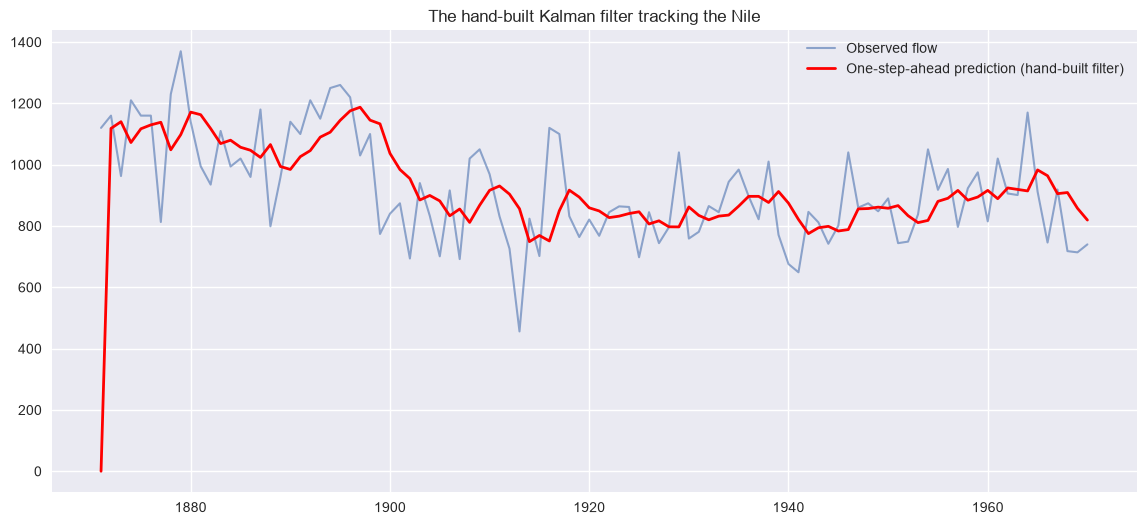

In [13]:
one_step = pd.Series(a[:-1], index=nile_y.index)      # a_t = prediction of y_t before seeing it

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, lw=1.5, alpha=0.6, label="Observed flow")
ax.plot(one_step.index, one_step.values, color="red", lw=2,
        label="One-step-ahead prediction (hand-built filter)")
ax.set_title("The hand-built Kalman filter tracking the Nile")
ax.set_xlabel(""); plt.legend(); plt.show()

This code generates a plot comparing the observed Nile River flow data with one-step-ahead predictions generated by the custom Kalman filter implemented in the `DKStateSpaceModel` class.

It first creates a Pandas Series called `one_step` containing the predicted state values (`a`) from the Kalman filter, excluding the last value (indicated by `[:-1]`). The index of this series is set to match the index of the original Nile River flow data (`nile_y`), ensuring proper alignment for comparison. These predictions represent the best estimate of the current observation *before* it is actually observed.

Then, a Matplotlib figure and axes object are created. The observed Nile River flow data (`nile_y`) is plotted as a semi-transparent line with a linewidth of 1.5, labeled "Observed flow".  The one-step-ahead predictions from the Kalman filter (`one_step`) are then plotted as a solid red line with a linewidth of 2, labeled “One-step-ahead prediction (hand-built filter)”.

Finally, the plot is titled "The hand-built Kalman filter tracking the Nile", the x-axis label is removed, a legend is displayed, and the plot is shown. This visualization allows for a direct assessment of how well the custom Kalman filter tracks the observed data over time, demonstrating its ability to provide accurate short-term predictions.

# The structural ladder

In [14]:
print(uc_res.summary())

                        Unobserved Components Results                         
Dep. Variable:                 volume   No. Observations:                  100
Model:                    local level   Log Likelihood                -632.538
Date:                Sun, 05 Jul 2026   AIC                           1269.076
Time:                        11:49:53   BIC                           1274.266
Sample:                    01-01-1871   HQIC                          1271.176
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.508e+04   2586.506      5.829      0.000       1e+04    2.01e+04
sigma2.level      1478.8117    851.329      1.737      0.082    -189.762    3147.386
Ljung-Box (L1) (Q):         

This code prints a detailed summary of the results from fitting the unobserved components model using `statsmodels`.

Specifically, it calls the `.summary()` method on the fitted `UnobservedComponents` object (`uc_res`). This method generates a comprehensive report that includes:

- Model parameters and their estimated values (e.g., variances of the level and observation noise).
- Standard errors, t-statistics, and p-values for each parameter, indicating the statistical significance of the estimates.
- Confidence intervals for the parameters.
- Information criteria such as AIC, BIC, and HQIC, which can be used to compare different models.
- Log-likelihood value.
- Residual diagnostics, including tests for autocorrelation and heteroscedasticity in the residuals.

The output is a multi-page report printed to the console, providing a thorough assessment of the model’s fit and the reliability of its parameter estimates. This summary is crucial for evaluating the quality of the fitted model and interpreting its results.

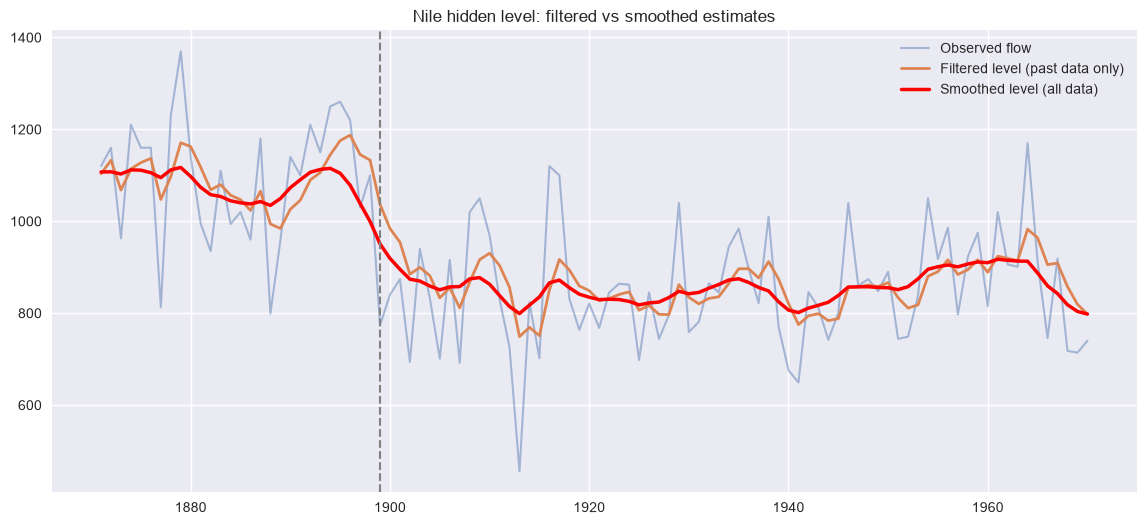

In [15]:
level_filtered = pd.Series(uc_res.level["filtered"], index=nile_y.index)
level_smoothed = pd.Series(uc_res.level["smoothed"], index=nile_y.index)

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, lw=1.5, alpha=0.45, label="Observed flow")
ax.plot(level_filtered.index, level_filtered.values, color="#DD8452", lw=2,
        label="Filtered level (past data only)")
ax.plot(level_smoothed.index, level_smoothed.values, color="red", lw=2.5,
        label="Smoothed level (all data)")
ax.axvline(pd.Timestamp("1899-01-01"), color="grey", linestyle="--", lw=1.5)
ax.set_title("Nile hidden level: filtered vs smoothed estimates")
ax.set_xlabel(""); plt.legend(); plt.show()

This code generates a plot comparing the filtered and smoothed estimates of the underlying level component in the Nile River flow data, as obtained from the `statsmodels` unobserved components model.

It first extracts the filtered and smoothed level estimates from the fitted `UnobservedComponents` object (`uc_res`). The `.level["filtered"]` attribute provides the state estimate based on information available up to that point in time (past data only), while `.level["smoothed"]` uses all available data (past and future) to produce a more accurate, but less timely, estimate. These estimates are then converted into Pandas Series with the same index as the original Nile River flow data (`nile_y`).

A Matplotlib figure and axes object are created. The observed Nile River flow is plotted as a semi-transparent line, labeled "Observed flow".  The filtered level estimate is plotted as a solid line in a salmon color (`#DD8452`), labeled “Filtered level (past data only)”. The smoothed level estimate is then plotted as a thicker red line, labeled “Smoothed level (all data)”.

A vertical dashed gray line is added to indicate the construction of the Aswan Dam. Finally, the plot is titled "Nile hidden level: filtered vs smoothed estimates", the x-axis label is removed, a legend is displayed, and the plot is shown. This visualization illustrates the difference between filtered and smoothed state estimates – the filtered estimate represents the best guess of the underlying level at each point in time based on past data, while the smoothed estimate provides a more accurate retrospective view using all available information.

## Local linear trend 

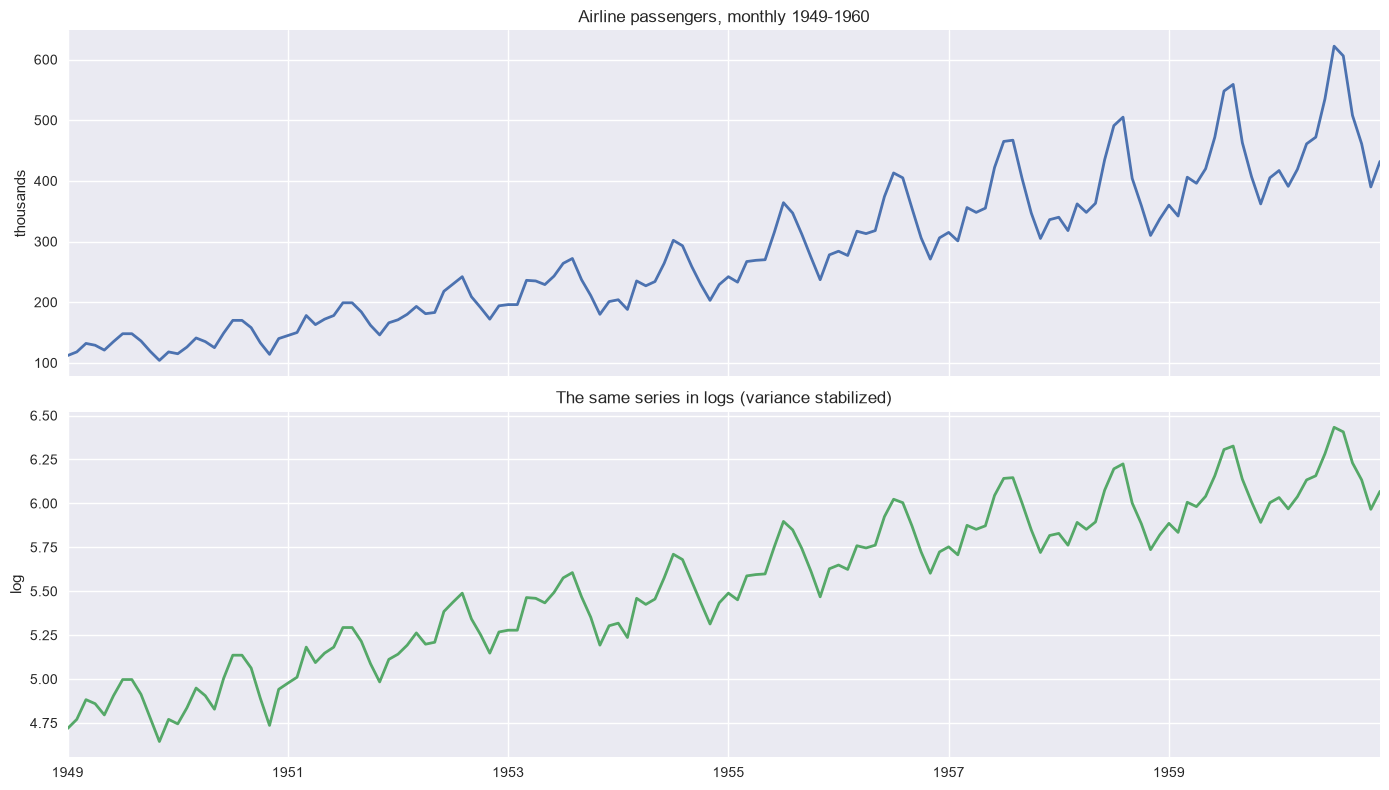

In [16]:
air = pd.read_csv(CFG.data_folder + "passengers.csv")
air["date"] = pd.to_datetime(air["date"])
y_air = air.set_index("date")["passengers"].astype(float).asfreq("MS")
log_air = np.log(y_air)

fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, 8), sharex=True)
y_air.plot(ax=axes[0], lw=2)
axes[0].set(title="Airline passengers, monthly 1949-1960", ylabel="thousands")
log_air.plot(ax=axes[1], lw=2, color="#55A868")
axes[1].set(title="The same series in logs (variance stabilized)", xlabel="", ylabel="log")
plt.tight_layout(); plt.show()

This code loads and prepares the airline passengers dataset for time series analysis, then visualizes both the original data and its logarithmic transformation.

It begins by reading the "passengers.csv" file from the directory specified in `CFG.data_folder` using `pd.read_csv()`. A new column named "date" is created by converting the existing date column to datetime objects using `pd.to_datetime()`. 

The data is then transformed into a time series: it sets the "date" column as the index of the DataFrame and selects the "passengers" column, converts it to a floating-point data type, and resamples it to monthly frequency ("MS") using `.asfreq("MS")`, storing the result in `y_air`. The natural logarithm of the time series is then calculated and stored in `log_air` using `np.log()`. This transformation is often applied to stabilize variance in time series data, making it more suitable for modeling.

Finally, two subplots are created using `plt.subplots(2, 1)`, sharing the x-axis. The original airline passengers data (`y_air`) is plotted on the top subplot with a linewidth of 2 and labeled appropriately. The logarithmic transformation of the data (`log_air`) is plotted on the bottom subplot, also with a linewidth of 2 and a different color (#55A868), and labeled accordingly. `plt.tight_layout()` adjusts subplot parameters for a tight layout, and `plt.show()` displays the resulting plot. This visualization demonstrates the effect of the logarithmic transformation on stabilizing the variance of the time series data.

Local linear trend: {'MAE': 76.41, 'RMSE': 100.68}


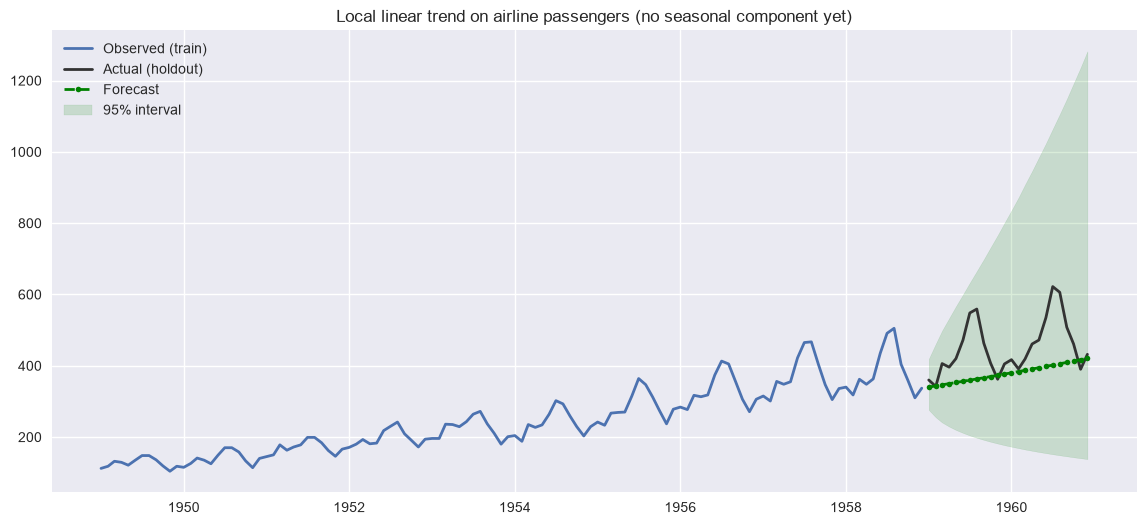

In [ ]:
log_train, log_valid = train_valid_split(log_air)
valid_orig = y_air.iloc[-CFG.HORIZON:]                  # holdout on the original scale

llt_res = sm.tsa.UnobservedComponents(log_train, level="local linear trend").fit(disp=False)

fc = llt_res.get_forecast(CFG.HORIZON)
llt_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("Local linear trend:", forecast_metrics(valid_orig, llt_pred))
plot_forecast(y_air.iloc[:-CFG.HORIZON], valid_orig, llt_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="Local linear trend on airline passengers (no seasonal component yet)")

This code fits a local linear trend model to the logarithm of the airline passenger data and evaluates its forecasting performance.

First, it splits the logarithmic time series (`log_air`) into training and validation sets using the `train_valid_split` function, reserving the last `CFG.HORIZON` months for validation. It also stores the original scale values of the validation set in `valid_orig` to allow for performance evaluation on the original units.

A local linear trend model is then fitted to the training data (`log_train`) using `statsmodels.tsa.UnobservedComponents`. The `fit()` method estimates the model parameters, and `disp=False` suppresses output during fitting. 

Next, it generates forecasts for the validation period using the `get_forecast()` method of the fitted model, specifying the forecast horizon (`CFG.HORIZON`). The predicted mean is exponentiated (`np.exp()`) to convert the forecast back to the original scale (passengers). Confidence intervals are also calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of the model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`llt_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. 

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the training data, the actual validation data, the forecasted values, and the confidence intervals. The plot is titled "Local linear trend on airline passengers (no seasonal component yet)". This allows for visual assessment of the model’s fit and forecasting accuracy.

## Basic structural model 

Basic structural model: {'MAE': 27.72, 'RMSE': 32.58}

estimated variances:
  sigma2.irregular     0.000141
  sigma2.level         0.000797
  sigma2.trend         0.000000
  sigma2.seasonal      0.000037


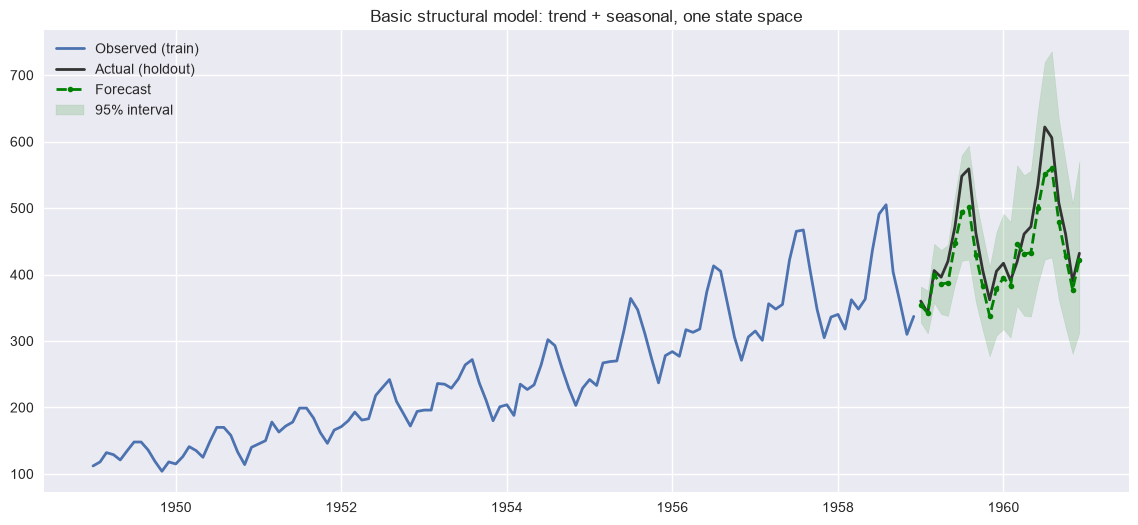

In [18]:
bsm_res = sm.tsa.UnobservedComponents(
    log_train,
    level="local linear trend",
    seasonal=CFG.SEASONAL_PERIODS,
).fit(disp=False)

fc = bsm_res.get_forecast(CFG.HORIZON)
bsm_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("Basic structural model:", forecast_metrics(valid_orig, bsm_pred))
print("\nestimated variances:")
for name, val in zip(bsm_res.param_names, bsm_res.params):
    print(f"  {name:20s} {val:.6f}")

plot_forecast(y_air.iloc[:-CFG.HORIZON], valid_orig, bsm_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="Basic structural model: trend + seasonal, one state space")

This code fits a basic structural time series model with both trend and seasonality to the logarithm of the airline passenger data and evaluates its forecasting performance.

It begins by fitting an unobserved components model using `statsmodels.tsa.UnobservedComponents` to the training data (`log_train`). This time, it specifies both a local linear trend (`level="local linear trend"`) and a seasonal component with a period of `CFG.SEASONAL_PERIODS` (12 for monthly data with an annual cycle). The model is fitted using the `fit()` method, suppressing output during fitting.

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`CFG.HORIZON`).  The predicted mean is exponentiated to convert it back to the original scale (passengers), and confidence intervals are calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`bsm_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. 

Additionally, it prints a list of estimated variances from the fitted model by iterating through the parameter names (`bsm_res.param_names`) and their corresponding values (`bsm_res.params`), formatting them for readability. This provides insight into the relative importance of different components in the model.

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the training data, actual validation data, forecasted values, and confidence intervals. The plot is titled "Basic structural model: trend + seasonal, one state space". This visualization allows for assessment of how well the inclusion of seasonality improves forecasting accuracy compared to the local linear trend model alone.

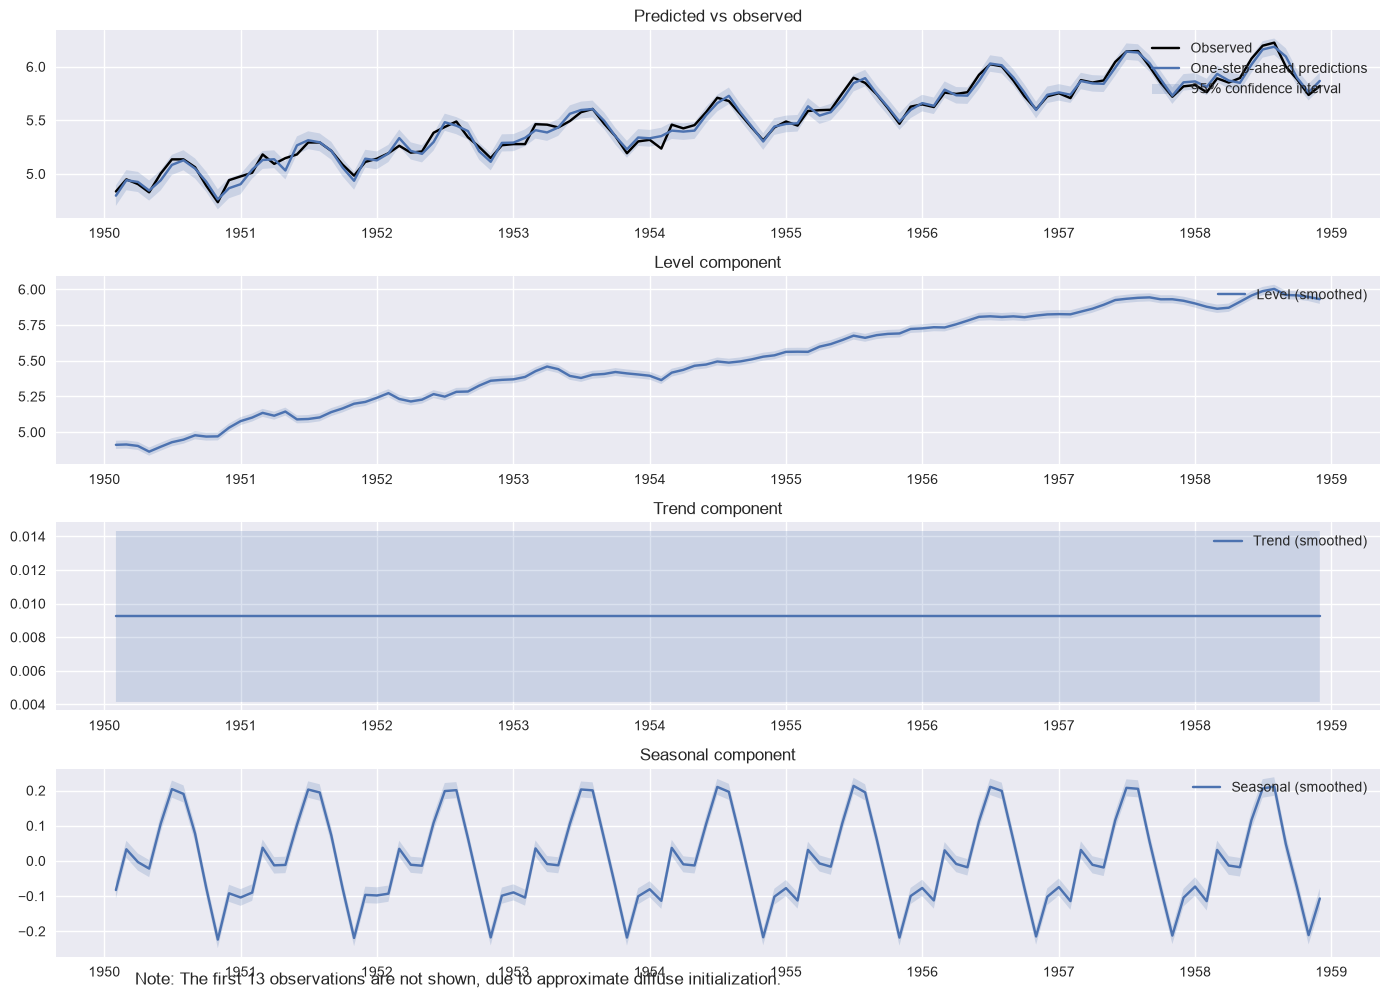

In [19]:
fig = bsm_res.plot_components(figsize=(CFG.img_dim1, CFG.img_dim2 + 4))
plt.tight_layout(); plt.show()

This code generates a plot displaying the components of the basic structural time series model fitted to the airline passenger data.

It calls the `plot_components()` method on the fitted `bsm_res` object (the result of fitting the unobserved components model). This method automatically creates a figure with subplots showing the estimated trend, seasonal, and irregular components of the time series. The `figsize` argument sets the size of the figure to match the configuration settings defined in `CFG`.

`plt.tight_layout()` adjusts subplot parameters for a tight layout, preventing overlapping elements. Finally, `plt.show()` displays the resulting plot. This visualization provides valuable insights into how the model decomposes the time series into its underlying components and helps understand the dynamics of the data.

# Unification

## ARIMA as a state space model (SARIMAX)

SARIMAX airline model: {'MAE': 39.45, 'RMSE': 43.19}


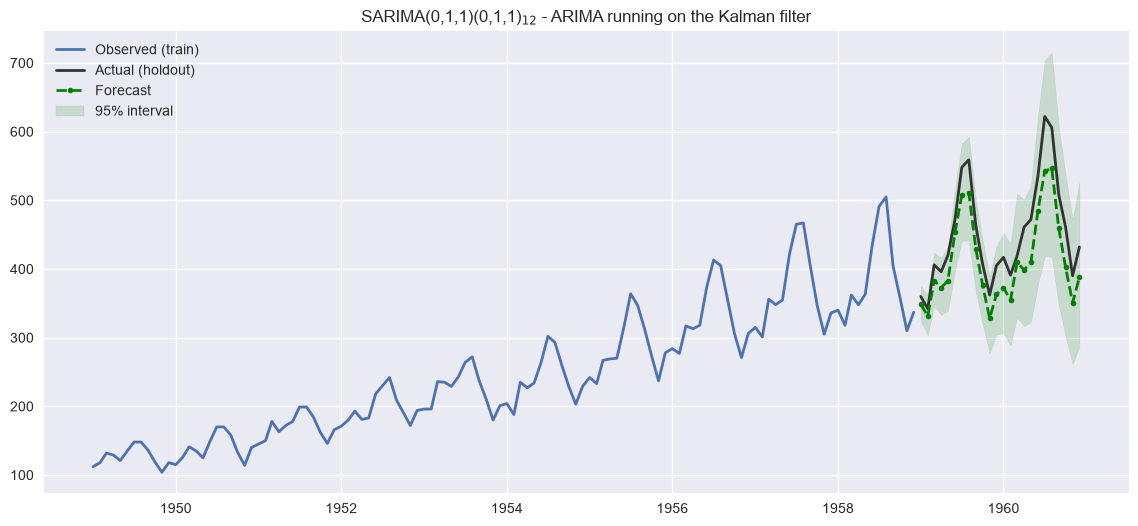

In [20]:
sarimax_res = sm.tsa.SARIMAX(log_train, order=(0, 1, 1),
                             seasonal_order=(0, 1, 1, CFG.SEASONAL_PERIODS)).fit(disp=False)

fc = sarimax_res.get_forecast(CFG.HORIZON)
sarimax_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("SARIMAX airline model:", forecast_metrics(valid_orig, sarimax_pred))
plot_forecast(y_air.iloc[:-CFG.HORIZON], valid_orig, sarimax_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="SARIMA(0,1,1)(0,1,1)$_{12}$ - ARIMA running on the Kalman filter")

This code fits a Seasonal Autoregressive Integrated Moving Average (SARIMAX) model to the logarithm of the airline passenger data and evaluates its forecasting performance.

It begins by fitting a SARIMAX model using `sm.tsa.SARIMAX` to the training data (`log_train`). The model is specified with an order of (0, 1, 1), representing zero autoregressive terms, one integration (differencing) term, and one moving average term. It also includes a seasonal component with an order of (0, 1, 1, `CFG.SEASONAL_PERIODS`), indicating zero seasonal autoregressive terms, one seasonal differencing term, one seasonal moving average term, and a seasonal period of 12 (monthly data with an annual cycle). The model is fitted using the `fit()` method, suppressing output during fitting.

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`CFG.HORIZON`).  The predicted mean is exponentiated to convert it back to the original scale (passengers), and confidence intervals are calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`sarimax_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. 

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the training data, actual validation data, forecasted values, and confidence intervals. The plot is titled "SARIMA(0,1,1)(0,1,1)$_{12}$ - ARIMA running on the Kalman filter". This visualization allows for assessment of how well the SARIMAX model captures both the trend and seasonal patterns in the airline passenger data and provides a comparison to the previously fitted structural time series models.

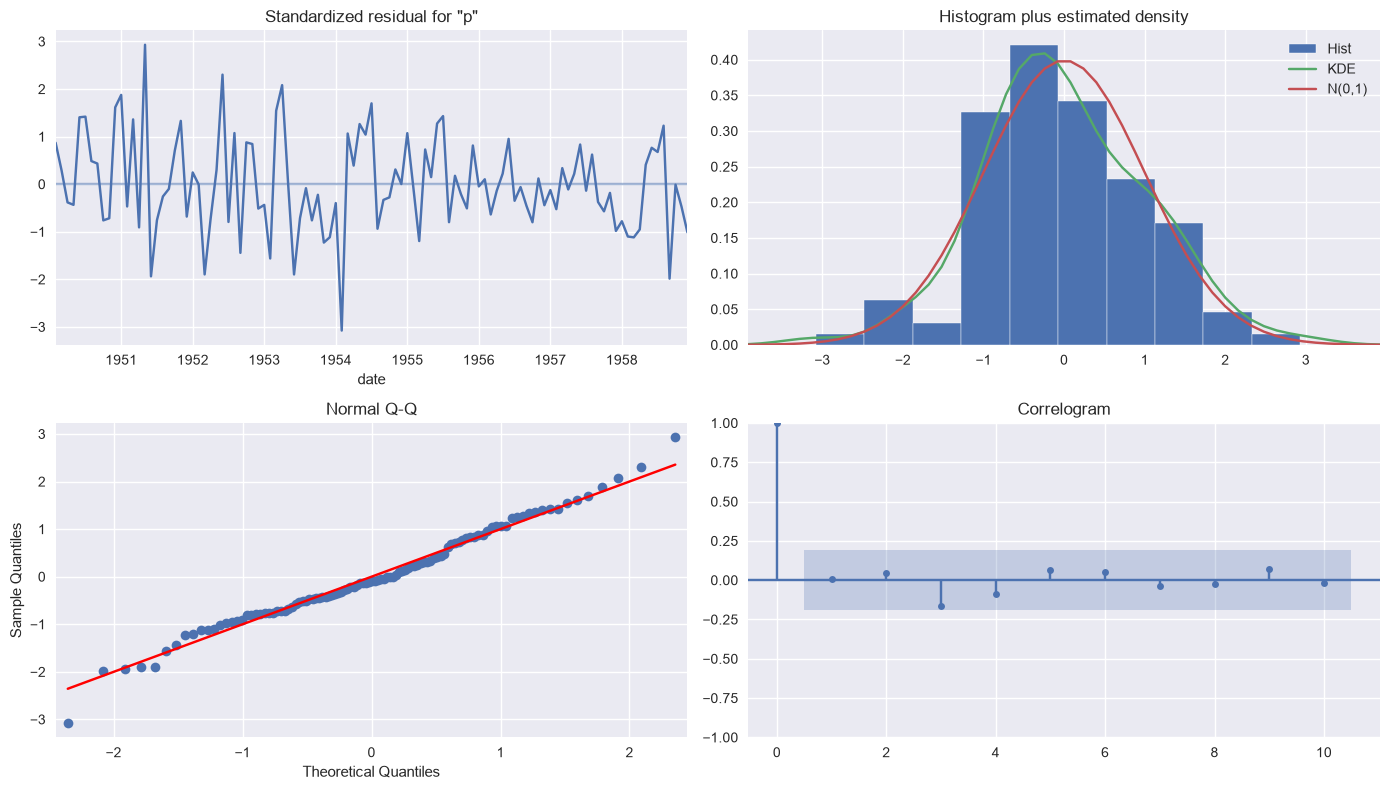

In [21]:
sarimax_res.plot_diagnostics(figsize=(CFG.img_dim1, CFG.img_dim2 + 2))
plt.tight_layout(); plt.show()

This code generates diagnostic plots for the fitted SARIMAX model to assess its adequacy and identify potential issues with the model fit.

It calls the `plot_diagnostics()` method on the fitted `sarimax_res` object (the result of fitting the SARIMAX model). This method automatically creates a figure containing several subplots designed to check various assumptions of the model, including:

- Autocorrelation and partial autocorrelation functions (ACF and PACF) of the residuals to assess whether any serial correlation remains.
- A histogram or density plot of the standardized residuals to check for normality.
- Q-Q plots to further evaluate the normality of the residuals.
- Plots of the residuals over time to identify potential patterns or heteroscedasticity (non-constant variance).

The `figsize` argument sets the size of the figure to match the configuration settings defined in `CFG`.  `plt.tight_layout()` adjusts subplot parameters for a tight layout, and `plt.show()` displays the resulting plot. These diagnostic plots are crucial for validating the model assumptions and ensuring that the SARIMAX model provides a reliable representation of the data.

## Exponential smoothing as a state space model (ETS / SSOE)

In [22]:
ets_res = ETSModel(log_train, error="add", trend="add", seasonal="add",
                   seasonal_periods=CFG.SEASONAL_PERIODS).fit(disp=False)

print("smoothing parameters (a.k.a. steady-state Kalman gains):")
for name, val in zip(ets_res.param_names, ets_res.params):
    if "smoothing" in name:
        print(f"  {name:22s} {val:.4f}")

ets_pred = np.exp(ets_res.forecast(CFG.HORIZON))
print("\nETS(A,A,A):", forecast_metrics(valid_orig, ets_pred))

smoothing parameters (a.k.a. steady-state Kalman gains):
  smoothing_level        0.9999
  smoothing_trend        0.0001
  smoothing_seasonal     0.0001

ETS(A,A,A): {'MAE': 31.77, 'RMSE': 36.95}


`ETSModel` with additive error, trend, and seasonal on the log scale is ETS(A,A,A) — Holt-Winters with a likelihood. It scores **RMSE ≈ 37**, between the structural model and the ARIMA, completing a tight three-way race among the seasonal models (33 / 37 / 43).

The estimated smoothing parameters tell their own story in the SSOE dialect. **α ≈ 1.0**: the level update absorbs essentially the whole of each innovation — on this smooth, strongly-trending series the "level" simply tracks the data. **β ≈ 0.0001 and γ ≈ 0.0001**: the trend and seasonal states barely update — effectively a fixed growth rate and a stable seasonal pattern. Which is, translated across frameworks, *the same verdict* the basic structural model reached when its trend variance went to zero and its seasonal variance came out tiny. Two parameterizations, one conclusion about the data — unification working exactly as advertised. (And because this ETS is a genuine state space model, that near-unit α came from `scipy.optimize` maximizing a real likelihood, with AIC available for comparing, say, additive against multiplicative variants — the thing the 1950s recursions could never legitimately do.)

# Custom models with MLEModel

The high-level classes cover the standard cases. The framework's real power is that you are not limited to them: subclass `MLEModel`, write down your own system matrices, and everything else — Kalman filtering, likelihood, optimizer, standard errors, forecasting, diagnostics — is inherited. To demystify the process we rebuild something whose answer we already know: the local linear trend, this time from raw matrices.

In [23]:
class LocalLinearTrend(MLEModel):
    """Local linear trend written directly in system matrices.

    state:  (mu_t, nu_t)        level and slope
    params: three variances (measurement, level shock, slope shock)
    """
    param_names = ["sigma2.irregular", "sigma2.level", "sigma2.trend"]
    start_params = [1.0, 1.0, 1.0]

    def __init__(self, endog):
        super().__init__(endog, k_states=2, k_posdef=2,
                         initialization="approximate_diffuse")
        self["design"] = np.array([[1.0, 0.0]])            # y_t = mu_t + eps
        self["transition"] = np.array([[1.0, 1.0],         # mu_{t+1} = mu_t + nu_t
                                       [0.0, 1.0]])        # nu_{t+1} = nu_t
        self["selection"] = np.eye(2)                      # each state gets its own shock

    def transform_params(self, unconstrained):
        return unconstrained ** 2                          # keep variances positive

    def untransform_params(self, constrained):
        return constrained ** 0.5

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]                  # H
        self["state_cov", 0, 0] = params[1]                # Q: level shock
        self["state_cov", 1, 1] = params[2]                # Q: slope shock

The anatomy of a custom model, piece by piece. In `__init__` we declare the dimensions (`k_states=2`, `k_posdef=2` — two states, two independent shocks) and fill the matrices that never change: the design row selecting the level into the observation, the transition matrix with its "position += velocity" structure, an identity selection matrix. `initialization="approximate_diffuse"` is our old friend from the hand-built filter — both states are random walks, so we profess ignorance about their starting values.

Two methods handle the parameters. `update` receives the current parameter vector during optimization and writes the three variances into `H` and the diagonal of `Q` — this is called at every optimizer step, so *changing* matrices go here while *fixed* ones stay in `__init__`. And the `transform_params` pair is a small but essential trick: the optimizer roams unconstrained over ℝ³, but variances must be positive, so we square on the way in and square-root on the way out. Forget this and `fit()` will eventually wander into negative variances and explode — the single most common bug in hand-rolled state space models.

In [24]:
custom_res = LocalLinearTrend(log_train).fit(disp=False)

check = pd.DataFrame({
    "custom MLEModel": np.round(custom_res.params, 6),
    "UnobservedComponents": np.round(llt_res.params, 6),
}, index=custom_res.param_names)
check

,custom MLEModel,UnobservedComponents
sigma2.irregular,0.000000,0.000000
sigma2.level,0.011203,0.011203
sigma2.trend,0.000000,0.000000


The exam: fit the hand-specified model on the same log airline training data and set the estimates beside `UnobservedComponents`' local linear trend from earlier. The variance estimates match to six decimals — the black box and our white box are the same box. (One footnote if you compare *log-likelihood values* between the two: they differ, because `UnobservedComponents` uses exact diffuse initialization while we chose the approximate variant — the same initialization-convention gotcha the Nile validation taught. Parameters agree; likelihood bookkeeping differs.)

Also worth noting what the estimates *say*: the measurement variance is squeezed to zero and the level shock carries everything — on the log scale this series is so smooth that the model deems each month's reading an essentially noiseless glimpse of a wandering level. When a variance hits a boundary like this, the model is telling you something structural about the data; listen.

# Application: missing data, handled natively

Time to cash the cheque the introduction wrote. Real archives have holes — instruments fail, wars interrupt record-keeping, files burn. Classical Box–Jenkins has no honest answer (impute first, then pretend you didn't). The Kalman filter's answer is built into its own recursion: when $y_t$ is missing, *skip the update step*. The prediction step still runs (the state coasts forward through $T$, uncertainty widening), the gain is simply never applied, and the likelihood skips a term. Then the smoother, running backward, uses post-gap data to pin down what happened inside the gap. Interpolation is not a preprocessing step; it is a posterior estimate from the same model.

We test this the honest way: cut a hole in the Nile, fit on the damaged series, and compare the model's reconstruction against the values we hid.

In [25]:
GAP_START, GAP_END = 40, 55                    # hide 15 consecutive years

nile_gapped = nile_y.copy().astype(float)
nile_gapped.iloc[GAP_START:GAP_END] = np.nan
hidden_truth = nile_y.iloc[GAP_START:GAP_END]
print(f"gap: {nile_gapped.index[GAP_START].year}-{nile_gapped.index[GAP_END-1].year}"
      f"  ({GAP_END - GAP_START} missing years)")

gap_res = sm.tsa.UnobservedComponents(nile_gapped, level="local level").fit(disp=False)

print("\nvariances fitted on gapped data :", np.round(gap_res.params, 0).astype(int).tolist())
print("variances fitted on full data   :", np.round(uc_res.params, 0).astype(int).tolist())

gap: 1911-1925  (15 missing years)

variances fitted on gapped data : [12813, 1870]
variances fitted on full data   : [15078, 1479]


We erase 1911–1925 — fifteen consecutive years, 15% of the sample — and refit the local level model directly on the series *with the NaNs in it*. No error, no imputation, no special arguments: the filter processes the gap by prediction alone, exactly as described.

First check: the variances estimated from the damaged series (≈ 12,800 and 1,870) land close to the full-data estimates (≈ 15,100 and 1,480). Fifteen missing years cost some precision but did not distort the model's understanding of the river — because the likelihood correctly *knows* those years are absent, rather than being fed made-up values that would masquerade as evidence.

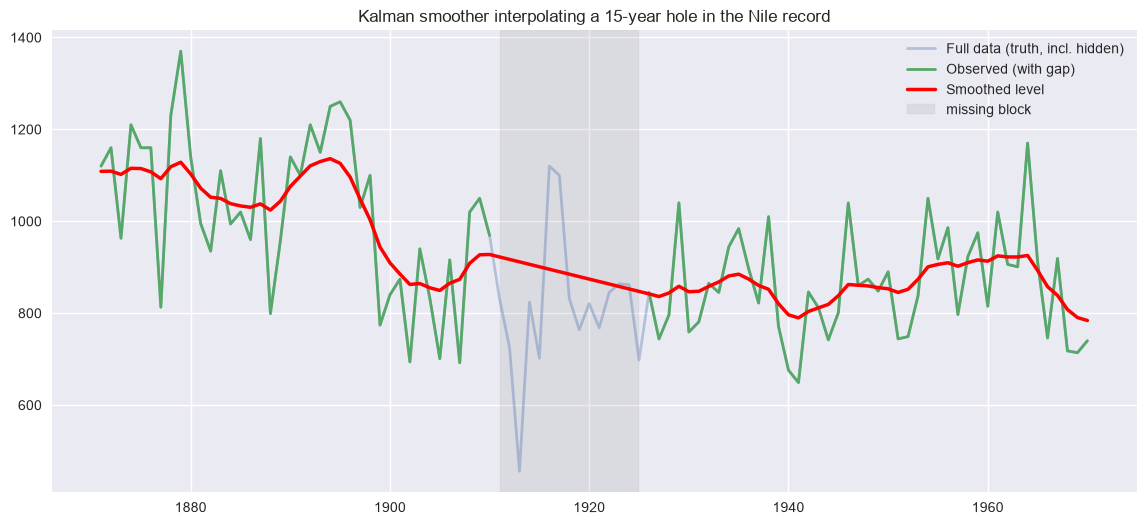

RMSE inside the gap - Kalman smoother   : 172.25
RMSE inside the gap - linear interpolation: 185.15


In [26]:
interp = pd.Series(gap_res.level["smoothed"], index=nile_gapped.index)
gap_slice = slice(GAP_START, GAP_END)

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, lw=2, alpha=0.35, label="Full data (truth, incl. hidden)")
ax.plot(nile_gapped.index, nile_gapped.values, lw=2, label="Observed (with gap)")
ax.plot(interp.index, interp.values, color="red", lw=2.5, label="Smoothed level")
ax.axvspan(nile_y.index[GAP_START], nile_y.index[GAP_END - 1], color="grey", alpha=0.15,
           label="missing block")
ax.set_title("Kalman smoother interpolating a 15-year hole in the Nile record")
ax.set_xlabel(""); plt.legend(); plt.show()

kalman_rmse = forecast_metrics(hidden_truth, interp.iloc[gap_slice])["RMSE"]
naive_rmse = forecast_metrics(hidden_truth, nile_gapped.interpolate().iloc[gap_slice])["RMSE"]
print("RMSE inside the gap - Kalman smoother   :", kalman_rmse)
print("RMSE inside the gap - linear interpolation:", naive_rmse)

The picture: through the shaded gap, the red smoothed level bridges the hole with a gently sloping line — which looks like interpolation, but with a crucial difference in what it connects. Naive interpolation joins the two *noisy observations* that happen to sit at the gap's edges; the smoother joins the model's *noise-filtered level estimates* there, each one already an average over many surrounding years. Against the hidden truth, the Kalman reconstruction scores **RMSE ≈ 172** versus **≈ 185** for naive linear interpolation.

An honest reading of that margin: real but modest — for a local level model, the optimal bridge across a gap genuinely *is* close to a level line, so there was limited room to beat the naive method on point accuracy. The deeper advantages are the ones the naive method cannot offer at any accuracy: the model reports *uncertainty* inside the gap (the state variance visibly inflates where data is absent, then contracts — linear interpolation is silently overconfident); the parameters were estimated correctly *despite* the hole; and the same mechanism scales unchanged to seasonal series, trends, and multivariate systems, where straight-line imputation becomes actively destructive. Missing-data handling is not a feature bolted onto the framework — it falls out of the filter's logic.

# Head-to-head: the seasonal forecasters

Three seasonal models fitted, one hold-out never touched twice: same training window, same 24-month test, same metric. The local linear trend joins as the seasonality-free baseline everyone should beat.

In [27]:
scores = {
    "LocalLinearTrend (no seasonal)": forecast_metrics(valid_orig, llt_pred)["RMSE"],
    "BasicStructural": forecast_metrics(valid_orig, bsm_pred)["RMSE"],
    "SARIMAX airline": forecast_metrics(valid_orig, sarimax_pred)["RMSE"],
    "ETS(A,A,A)": forecast_metrics(valid_orig, ets_pred)["RMSE"],
}
compare_models(scores, baseline="LocalLinearTrend (no seasonal)")

,RMSE,delta_vs_baseline,improved
model,,,
BasicStructural,32.58,-68.10,True
"ETS(A,A,A)",36.95,-63.73,True
SARIMAX airline,43.19,-57.49,True
LocalLinearTrend (no seasonal),100.68,0.00,False


The table ranks the race. All three seasonal models demolish the trend-only baseline — cutting its error by 55–70% — which quantifies what the eye already knew: on this series, *seasonality is most of the forecastable signal*. Among the three, the **basic structural model** leads, **ETS** follows a few passengers behind, and the **SARIMAX airline model** trails while remaining entirely respectable.

Resist the ranking's gravity, though: this is one series and one horizon, and the honest headline is that three models from historically *rival* traditions — structural, smoothing, Box–Jenkins — land within about ten passengers RMSE of each other, because under the hood they are one framework making three sets of assumptions about the same matrices. The M-competitions' old verdict (no family dominates everywhere) survives its state space reformulation intact.

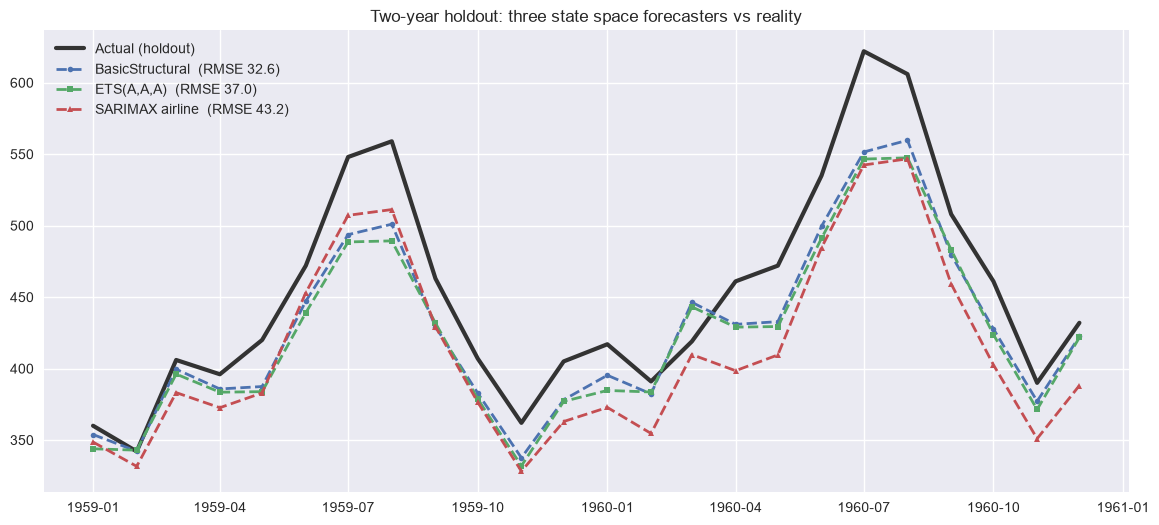

In [28]:
fig, ax = plt.subplots()
ax.plot(valid_orig.index, valid_orig.values, lw=3, color="#333333", label="Actual (holdout)")
ax.plot(valid_orig.index, bsm_pred.values, lw=2, linestyle="--", marker="o", markersize=4,
        label=f"BasicStructural  (RMSE {scores['BasicStructural']:.1f})")
ax.plot(valid_orig.index, ets_pred.values, lw=2, linestyle="--", marker="s", markersize=4,
        label=f"ETS(A,A,A)  (RMSE {scores['ETS(A,A,A)']:.1f})")
ax.plot(valid_orig.index, sarimax_pred.values, lw=2, linestyle="--", marker="^", markersize=4,
        label=f"SARIMAX airline  (RMSE {scores['SARIMAX airline']:.1f})")
ax.set_title("Two-year holdout: three state space forecasters vs reality")
ax.set_xlabel(""); plt.legend(); plt.show()

The overlay is the table's story in pictures: all three forecasts lock onto the seasonal shape, peaks and troughs in the right months, and all three undershoot the holdout's strongest summer peaks — 1959–60 traffic grew even faster than the sample's already-brisk trend. The differences are of degree: the structural model rides highest and closest, ETS a shade below it, and the SARIMAX runs consistently a notch low — its double differencing anchors the forecast to the most recent observed level, and a holdout that keeps accelerating steadily pulls away from that anchor. Differences of degree between siblings, not differences of kind between rivals.

# Conclusion

We climbed from a forty-line hand-built Kalman filter — validated to machine precision against statsmodels on a real river — up through the structural ladder (level → +slope → +seasonality), watched ARIMA and exponential smoothing collapse into the same two-equation framework, built a model from raw matrices, and put the machinery to work on the problem classical methods dodge: missing data, handled by the filter's own logic rather than by preprocessing.

The single mental model to keep: **a state space model is two equations and five matrices.** Everything else in this notebook was a consequence — the Kalman filter as the recursive estimator, the prediction error decomposition as the likelihood, filtering versus smoothing as real-time versus hindsight, diffuse initialization as honest ignorance, ETS's α as a frozen Kalman gain, and NaN-tolerance as a filter that simply skips an update.

A summary of the transformations we met:

| model | state dim | error sources | signature matrix feature |
| :--- | :--- | :--- | :--- |
| Local level | 1 | multiple (obs + level) | $T = Z = R = 1$ |
| Local linear trend | 2 | multiple | $T$ has the "position += velocity" block |
| Basic structural | 2 + 11 | multiple | seasonal states constrained to sum to zero |
| ARIMA(p,d,q) | max(p, q+1) (+d) | **one** shock | AR coeffs in $T$'s first column, MA coeffs in $R$ |
| ETS / SSOE | 1–13 | **one** shock, shared | $R$ = the smoothing parameters themselves |

Where next from here: the same framework extends to multivariate systems (dynamic factor models), time-varying regression coefficients, and — via simulation smoothing and particle filters — to non-Gaussian and nonlinear territory where the Kalman recursions become building blocks inside Bayesian samplers. Different destinations, same two equations.